# Sales Prediction Using Python 📈

## CodSoft Data Science Internship — Task 4

### Objective
Build a Machine Learning model to predict sales based on advertising expenditure across TV, radio, and newspaper platforms.

## 1. Project Overview

This project uses advertising expenditure data to predict product sales.

The dataset contains advertising budgets for:

- TV
- Radio
- Newspaper

The target variable is:

- Sales

A Linear Regression model is used to learn the relationship between advertising expenditure and sales.

## 2. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Data Exploration

In [4]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [7]:
df.shape

(200, 5)

In [8]:
df.columns

Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [10]:
df = df.drop('Unnamed: 0', axis=1)

In [11]:
print("Dataset shape:", df.shape)

Dataset shape: (200, 4)


In [12]:
print(df.columns)

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [14]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [15]:
df.isnull().sum()

,0
TV,0
radio,0
newspaper,0
sales,0


## 4. Exploratory Data Analysis

### Key Observations

- TV advertising shows a clear positive relationship with sales.
- Radio advertising also shows a positive relationship with sales.
- Newspaper advertising shows a weaker relationship with sales compared with TV and radio.

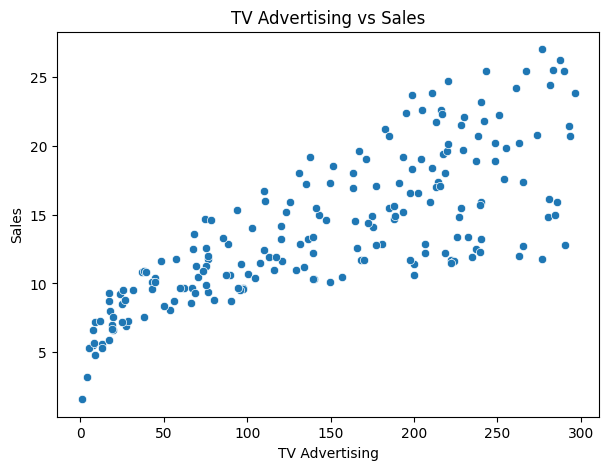

In [16]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='TV', y='sales')

plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')

plt.show()

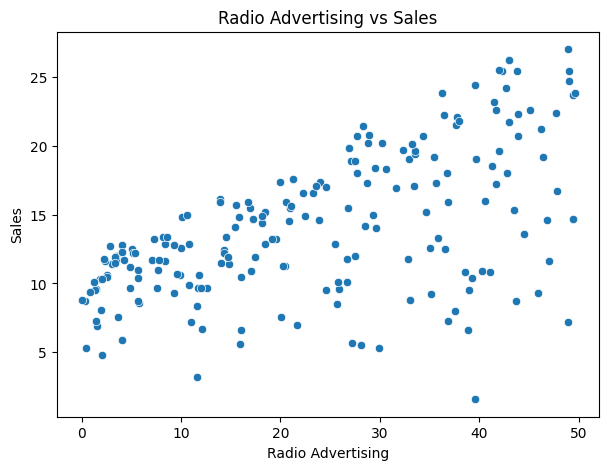

In [17]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='radio', y='sales')

plt.title('Radio Advertising vs Sales')
plt.xlabel('Radio Advertising')
plt.ylabel('Sales')

plt.show()

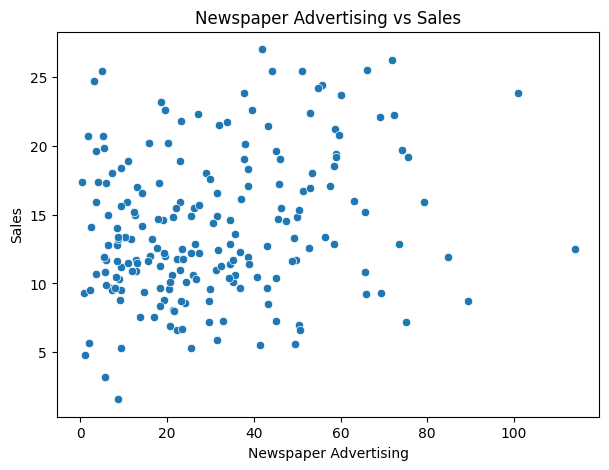

In [18]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='newspaper', y='sales')

plt.title('Newspaper Advertising vs Sales')
plt.xlabel('Newspaper Advertising')
plt.ylabel('Sales')

plt.show()

## 5. Correlation Analysis

In [19]:
correlation = df.corr()

print(correlation)

                 TV     radio  newspaper     sales
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000


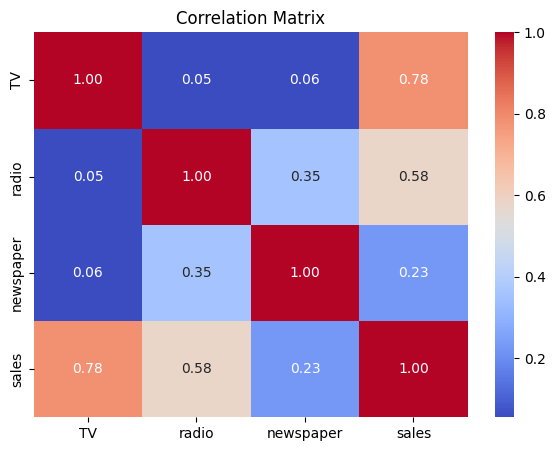

In [20]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

## 6. Feature and Target Selection

The input features are:

- TV
- Radio
- Newspaper

The target variable is:

- Sales

In [21]:
X = df[['TV', 'radio', 'newspaper']]

In [22]:
y = df['sales']

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


In [24]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [25]:
y.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


## 7. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to train the model, while the testing data is used to evaluate its performance.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (160, 3)
X_test: (40, 3)
y_train: (160,)
y_test: (40,)


## 8. Model Training

### Linear Regression

Linear Regression is used to model the relationship between advertising expenditure and sales.

In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [29]:
print("Model trained successfully!")

Model trained successfully!


## 9. Sales Prediction

In [30]:
y_pred = model.predict(X_test)

print(y_pred)

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967  9.04831992  6.65328312
 14.34554487  8.90349333  9.68959028 12.16494386  8.73628397 16.26507258
 10.27759582 18.83109103 19.56036653 13.25103464 12.33620695 21.30695132
  7.82740305  5.80957448 20.75753231 11.98138077  9.18349576  8.5066991
 12.46646769 10.00337695 21.3876709  12.24966368 18.26661538 20.13766267
 14.05514005 20.85411186 11.0174441   4.56899622]


In [31]:
print("Actual Sales:")
print(y_test.values)

print("\nPredicted Sales:")
print(y_pred)

Actual Sales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9]

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967  9.04831992  6.65328312
 14.34554487  8.90349333  9.68959028 12.16494386  8.73628397 16.26507258
 10.27759582 18.83109103 19.56036653 13.25103464 12.33620695 21.30695132
  7.82740305  5.80957448 20.75753231 11.98138077  9.18349576  8.5066991
 12.46646769 10.00337695 21.3876709  12.24966368 18.26661538 20.13766267
 14.05514005 20.85411186 11.0174441   4.56899622]


## 10. Model Evaluation

The model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [32]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.4607567168117603
MSE: 3.1740973539761033
RMSE: 1.78159966153345
R² Score: 0.899438024100912


## 11. Actual vs Predicted Sales

The actual sales values are compared with the sales values predicted by the Linear Regression model.

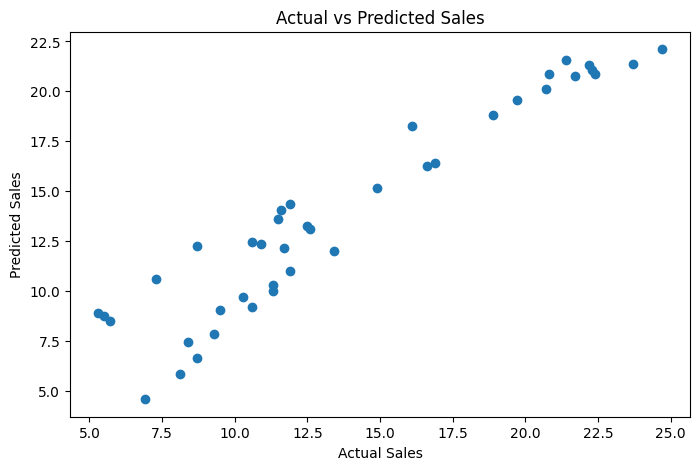

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

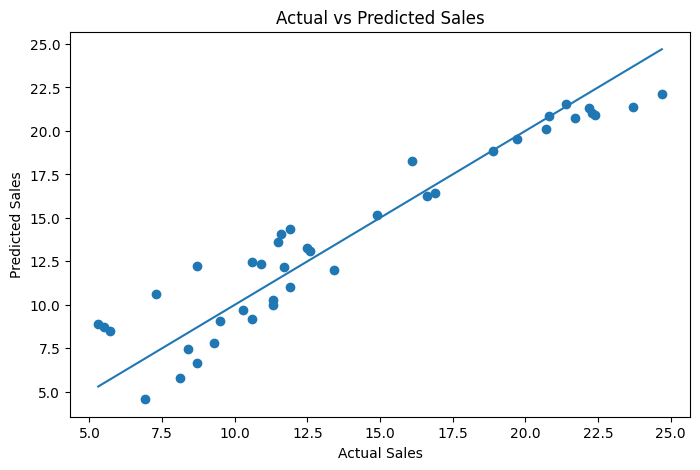

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## 12. New Sales Prediction

A new advertising budget is provided to the trained model to predict expected sales.

### Advertising Budget

- TV: 150
- Radio: 25
- Newspaper: 20

### Predicted Sales

**14.47**

In [35]:
new_ad = pd.DataFrame({
    'TV': [150],
    'radio': [25],
    'newspaper': [20]
})

In [36]:
predicted_sales = model.predict(new_ad)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 14.473593601116836


In [37]:
print("Advertising Budget:")
print("TV:", new_ad['TV'][0])
print("Radio:", new_ad['radio'][0])
print("Newspaper:", new_ad['newspaper'][0])

print("\nPredicted Sales:", round(predicted_sales[0], 2))

Advertising Budget:
TV: 150
Radio: 25
Newspaper: 20

Predicted Sales: 14.47


## 13. Conclusion

In this project, a Linear Regression model was developed to predict sales based on advertising expenditure.

The dataset was explored and visualized to understand the relationship between advertising platforms and sales. The data was then divided into training and testing sets, followed by model training and evaluation.

The model was also used to predict sales for a new advertising budget.

For a budget of TV = 150, Radio = 25, and Newspaper = 20, the model predicted sales of approximately **14.47 units**.

This project demonstrates a complete Machine Learning regression workflow from data exploration to prediction.